# Student Information
**Name:** Faisal AL Zahrani  
**Student ID:** 2230000363  
**Lab:** Lab 5 — Text Representation

# Text Representation

Text representation in NLP means converting text into a numerical form that a machine learning model can understand and process.

## What is Embedding?
An embedding represents a word as a dense numerical vector learned from context. Words used in similar contexts can have similar vectors.

This notebook studies two text representations: **TF-IDF**, a sparse document representation based on term counts, and **Word2Vec**, a learned dense word embedding. TF-IDF is not itself a learned semantic word embedding. These representations can provide features for downstream models such as SVMs and random forests.

| Representation | Unit | Main information |
|---|---|---|
| TF-IDF | Document | Weighted occurrence of vocabulary terms |
| Word2Vec | Word | Patterns of nearby words in the training corpus |

[Original embedding illustration](https://drive.google.com/uc?export=view&id=1jd0u_sGppDKqBYbhtJfGxp14lnUWUTTw)

# 1- TF-IDF
[Original TF-IDF illustration](https://drive.google.com/uc?export=view&id=1saSt0mMgOQ2ybbTms1lu_ruhUcBWkKzL)

TF-IDF stands for term frequency-inverse document frequency. It is a measure that discounts common words. Used in the fields of information retrieval (IR) and machine learning, that can quantify the importance of words in a document amongst a collection of documents (also known as a corpus).

### Components of TF-IDF

1. **TF (Term Frequency):**  
   Measures how frequently a term appears in a document.


$$ \text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d} $$


2. **IDF (Inverse Document Frequency):**  
   Measures how important a term is across all documents. Words that appear in many documents get lower scores.

$$    \text{IDF}(t) = \log \left(\frac{\text{Number of all documents N}}{\text{Number of documents containing the term } t}\right) $$

### TF-IDF Used in the Code
The preceding formulas show the basic idea. Scikit-learn's default `TfidfVectorizer` uses raw term counts, smoothed IDF, and L2 normalization:

$$\operatorname{idf}(t)=\log\left(\frac{1+N}{1+\operatorname{df}(t)}\right)+1,\quad
x_{t,d}=\operatorname{count}(t,d)\operatorname{idf}(t),\quad
\hat{x}_d=\frac{x_d}{\|x_d\|_2}.$$

Default tokenization lowercases words, ignores punctuation, and keeps tokens of at least two characters; the one-letter word **a** is excluded.

[Original worked TF-IDF illustration](https://drive.google.com/uc?export=view&id=1JqPILC8TTh3yDQZCSuPNXwm6ER5YeJFh)

### Environment Setup
Use **Python 3.12** for the verified Gensim environment. Run cells in order. The setup installs missing packages only; the README records tested versions.

Computed tables and the task plot are saved in the notebook. The five original Google Drive illustrations could not be retrieved during preparation; their links remain as references. The written explanations and results are self-contained.

No NLTK corpus download is needed because tokenization uses `preserve_line=True`. Both Word2Vec models use the full nonempty input corpora.

In [1]:
import importlib.util
import importlib.metadata
import subprocess
import sys

requirements = {
    "pandas": ("pandas", "pandas==3.0.1"),
    "numpy": ("numpy", "numpy>=1.26,<3"),
    "sklearn": ("scikit-learn", "scikit-learn==1.8.0"),
    "matplotlib": ("matplotlib", "matplotlib==3.10.7"),
    "nltk": ("nltk", "nltk==3.9.2"),
    "gensim": ("gensim", "gensim==4.4.0"),
}
missing = [requirement for module, (_, requirement) in requirements.items()
           if importlib.util.find_spec(module) is None]
if importlib.util.find_spec("gensim") is None and sys.version_info >= (3, 14):
    raise RuntimeError("Select a Python 3.12 kernel before installing Gensim for this lab.")
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
print("Python:", sys.version.split()[0])
for package, _ in requirements.values():
    print(f"{package}: {importlib.metadata.version(package)}")

import pandas as pd
import numpy as np
from IPython.display import display, Markdown
RANDOM_SEED = 42
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)

Python: 3.12.14
pandas: 3.0.1
numpy: 2.3.5
scikit-learn: 1.8.0
matplotlib: 3.10.7
nltk: 3.9.2
gensim: 4.4.0


In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]


In [4]:
tfidf = TfidfVectorizer()
result = tfidf.fit_transform(data)  # Sparse document-term matrix.
print("TF-IDF matrix shape:", result.shape)

TF-IDF matrix shape: (2, 8)


In [5]:
df = pd.DataFrame(result.toarray(), columns=tfidf.get_feature_names_out(),
                  index=["Document 1", "Document 2"])
display(df.round(4))
assert np.allclose(np.linalg.norm(result.toarray(), axis=1), 1.0)

,data,digital,economy,is,new,of,oil,the
Document 1,0.2438,0.3426,0.3426,0.2438,0.0000,0.3426,0.2438,0.6852
Document 2,0.4483,0.0000,0.0000,0.4483,0.6301,0.0000,0.4483,0.0000


# Cosine Similarity
Cosine similarity compares vector directions:

$$\operatorname{cosine}(A,B)=\frac{A\cdot B}{\|A\|\|B\|}.$$

$A\cdot B$ is the dot product; $\|A\|$ and $\|B\|$ are vector lengths. For nonzero vectors, equal directions give 1, orthogonal directions give 0, and opposite directions give -1. TF-IDF vectors are nonnegative, so their cosine similarity lies between 0 and 1.

With TF-IDF, zero indicates no overlap among represented terms; it does not prove the texts are semantically unrelated.

[Original cosine illustration](https://drive.google.com/uc?export=view&id=1b-o8CVfHBsjUGY_hXmxevU91gHidIuxO)

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
# Sample text data (replace with your own documents)

doc_1 = "Data is the oil of the digital economy"
doc_2 = "Data is a new oil"

data = [doc_1, doc_2]

In [8]:
tfidf_vectorizer = TfidfVectorizer()  # Create a TF-IDF vectorizer.
vector_matrix = tfidf_vectorizer.fit_transform(data)

In [9]:
cosine_similarity_matrix = cosine_similarity(vector_matrix)
df_cosine = pd.DataFrame(cosine_similarity_matrix,
                         index=["Document 1", "Document 2"],
                         columns=["Document 1", "Document 2"])
display(df_cosine.round(4))
print(f"Similarity of the two example documents: {cosine_similarity_matrix[0, 1]:.6f}")
assert np.allclose(cosine_similarity_matrix, cosine_similarity_matrix.T)
assert np.allclose(np.diag(cosine_similarity_matrix), 1.0)

,Document 1,Document 2
Document 1,1.0000,0.3279
Document 2,0.3279,1.0000


Similarity of the two example documents: 0.327871


# 2- What is Word2vec?

Word2Vec learns word vectors with shallow neural architectures:
1. **CBOW:** predict a target word from surrounding words.
2. **Skip-gram:** predict surrounding words from a target word.

[Original architecture illustration](https://drive.google.com/uc?export=view&id=1K38nEu_KhgtSJuG2RySwc6U5AAjVAgWZ)

The setup installs Gensim if missing (equivalent to `pip install gensim`). The introductory experiment uses **True.csv** from the [Fake and Real News dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset?select=True.csv), version 1.

Both models keep the lab's `min_count=1`, `vector_size=100`, `window=5`, and `sg=1`. Additional settings are `seed=42`, `workers=1`, `epochs=5`, and a stable hash function for repeatable runs with the same software and data. Results can differ across versions or platforms.

In [10]:
import pandas as pd
import nltk
import numpy as np
import gensim
import zlib
import time
from nltk.tokenize import word_tokenize
from gensim.models.callbacks import CallbackAny2Vec

def stable_hash(word):
    return zlib.crc32(word.encode("utf-8"))

class EpochProgress(CallbackAny2Vec):
    def __init__(self, label):
        self.label = label
        self.epoch = 0

    def on_epoch_end(self, model):
        self.epoch += 1
        print(f"{self.label}: epoch {self.epoch}/{model.epochs} completed.", flush=True)

In [11]:
from pathlib import Path
from urllib.request import Request, urlopen
import hashlib
import io
import zipfile

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
NEWS_ARCHIVE = DATA_DIR / "fake_and_real_news_v1.zip"
NEWS_SHA256 = "ba0844414a65dc6ae7402b8eee5306da24b6b56488d6767135af466c7dcb2775"

if not NEWS_ARCHIVE.exists():
    url = ("https://www.kaggle.com/api/v1/datasets/download/"
           "clmentbisaillon/fake-and-real-news-dataset?datasetVersionNumber=1")
    try:
        with urlopen(Request(url, headers={"User-Agent": "Mozilla/5.0"}), timeout=180) as response:
            archive_bytes = response.read()
    except Exception as exc:
        raise RuntimeError(
            "Download version 1 from the cited Kaggle source and save its ZIP as "
            "data/fake_and_real_news_v1.zip, then rerun."
        ) from exc
    if not zipfile.is_zipfile(io.BytesIO(archive_bytes)):
        raise RuntimeError("The news download is not a ZIP archive.")
    NEWS_ARCHIVE.write_bytes(archive_bytes)

with zipfile.ZipFile(NEWS_ARCHIVE) as archive:
    true_csv_bytes = archive.read("True.csv")
assert hashlib.sha256(true_csv_bytes).hexdigest() == NEWS_SHA256
news_df = pd.read_csv(io.BytesIO(true_csv_bytes), encoding="utf-8")
print(f"True.csv: {len(news_df):,} rows and {len(news_df.columns)} columns.")
display(news_df.head())
display(news_df.isna().sum().rename("Missing values").to_frame())

True.csv: 21,417 rows and 4 columns.


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script",WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congr...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',WASHINGTON (Reuters) - The special counsel investigation of links between Russia and P...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,WASHINGTON (Reuters) - Trump campaign adviser George Papadopoulos told an Australian d...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,SEATTLE/WASHINGTON (Reuters) - President Donald Trump called on the U.S. Postal Servic...,politicsNews,"December 29, 2017"


,Missing values
title,0
text,0
subject,0
date,0


### Tokenize the News Corpus
Treat each article as a separate sequence, preserving case and punctuation to follow the original example. Remove only missing or empty sequences. All articles are loaded with strict CSV parsing; no malformed rows are silently skipped.

In [12]:
# Preserve case/punctuation as in the original example.
# preserve_line=True avoids downloading a sentence-tokenizer resource.
news_text = news_df["text"].dropna()
news_tokens = [word_tokenize(text, preserve_line=True) for text in news_text]
news_empty_count = sum(not sentence for sentence in news_tokens)
news_tokens = [sentence for sentence in news_tokens if sentence]
news_token_count = sum(map(len, news_tokens))
print(f"Nonempty article sequences: {len(news_tokens):,}")
print(f"Empty sequences removed: {news_empty_count:,}; news tokens: {news_token_count:,}")

Nonempty article sequences: 21,416
Empty sequences removed: 1; news tokens: 9,033,146


### Train the News Skip-gram Example
Train the specified 100-dimensional model, then answer both original queries: the similarity of **provide/program** and the ten nearest words to **program**. Single-worker training may take a few minutes.

In [13]:
start_time = time.perf_counter()
w2v = gensim.models.Word2Vec(
    news_tokens, min_count=1, vector_size=100, window=5, sg=1,
    seed=RANDOM_SEED, workers=1, epochs=5, hashfxn=stable_hash,
    callbacks=[EpochProgress("News Skip-gram")],
)
news_training_seconds = time.perf_counter() - start_time
print(f"News vocabulary: {len(w2v.wv):,} words; vector size: {w2v.vector_size}")
print(f"Training time: {news_training_seconds:.1f} seconds")
assert w2v.sg == 1 and w2v.vector_size == 100 and w2v.window == 5
assert w2v.corpus_count == len(news_tokens)

News Skip-gram: epoch 1/5 completed.


News Skip-gram: epoch 2/5 completed.


News Skip-gram: epoch 3/5 completed.


News Skip-gram: epoch 4/5 completed.


News Skip-gram: epoch 5/5 completed.


News vocabulary: 114,680 words; vector size: 100
Training time: 339.4 seconds


In [14]:
assert {"provide", "program"}.issubset(w2v.wv.key_to_index)
news_similarity = float(w2v.wv.similarity("provide", "program"))
print(f"Cosine similarity between 'provide' and 'program' — Skip-gram: {news_similarity:.6f}")

Cosine similarity between 'provide' and 'program' — Skip-gram: 0.432902


In [15]:
news_neighbors = w2v.wv.most_similar("program", topn=10)
display(pd.DataFrame(news_neighbors, columns=["Word similar to program", "Cosine similarity"]))

,Word similar to program,Cosine similarity
0,program.,0.806374
1,programme,0.805607
2,programs,0.777993
3,accelerates,0.713759
4,EB-5,0.708538
5,arsenal,0.704923
6,programme.,0.693057
7,entitlement,0.689385
8,abolishing,0.674534
9,plan,0.668967


# Tasks

### Task Checklist
1. Calculate cosine similarity for all four sentences.
2. Calculate TF-IDF and identify important words in all three documents.
3. Clean **spoken_words** and train the specified Simpsons Skip-gram model.
4. Find words similar to **homer**, **marge**, and **bart**.
5. Find the odd word in each of the three lists.

The preceding TF-IDF, cosine, and news Word2Vec examples are also executed in their original order.

### Task 1: Cosine Similarity
Use the Cosine Similarity method to determine how similar the following sentences are.

'This is the first document.',  
'This document is the second document.',  
'And this is the third one.',  
'Is this the first document?'  


**Method:** Use default TF-IDF to represent the four sentences. Compute the complete cosine matrix and all six distinct sentence pairs.

In [16]:
task1_sentences = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]
task1_ids = ["S1", "S2", "S3", "S4"]
display(pd.DataFrame({"Sentence": task1_ids, "Text": task1_sentences}))
task1_vectorizer = TfidfVectorizer()
task1_vectors = task1_vectorizer.fit_transform(task1_sentences)
task1_similarity = cosine_similarity(task1_vectors)
display(pd.DataFrame(task1_similarity, index=task1_ids, columns=task1_ids).round(6))

from itertools import combinations
task1_pairs = pd.DataFrame([
    {"Sentence pair": f"S{i+1} / S{j+1}", "Cosine similarity": task1_similarity[i, j]}
    for i, j in combinations(range(len(task1_sentences)), 2)
]).sort_values("Cosine similarity", ascending=False, kind="stable").reset_index(drop=True)
display(task1_pairs)
assert np.allclose(task1_similarity, task1_similarity.T)
assert np.allclose(np.diag(task1_similarity), 1.0)
assert np.isclose(task1_similarity[0, 3], 1.0)
print("S1 and S4 are the most similar pair (1.0): they contain the same represented words.")
print("Default TF-IDF ignores word order, punctuation, and case.")

,Sentence,Text
0,S1,This is the first document.
1,S2,This document is the second document.
2,S3,And this is the third one.
3,S4,Is this the first document?


,S1,S2,S3,S4
S1,1.000000,0.646926,0.307772,1.000000
S2,0.646926,1.000000,0.225240,0.646926
S3,0.307772,0.225240,1.000000,0.307772
S4,1.000000,0.646926,0.307772,1.000000


,Sentence pair,Cosine similarity
0,S1 / S4,1.000000
1,S1 / S2,0.646926
2,S2 / S4,0.646926
3,S1 / S3,0.307772
4,S3 / S4,0.307772
5,S2 / S3,0.225240


S1 and S4 are the most similar pair (1.0): they contain the same represented words.
Default TF-IDF ignores word order, punctuation, and case.


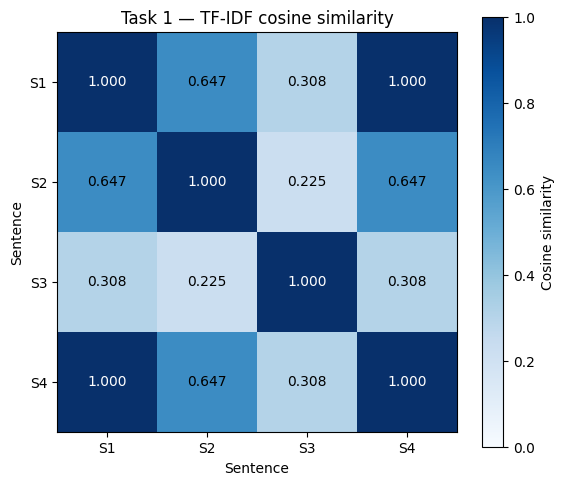

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.8, 5))
image = ax.imshow(task1_similarity, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(4), labels=task1_ids)
ax.set_yticks(range(4), labels=task1_ids)
ax.set_xlabel("Sentence")
ax.set_ylabel("Sentence")
ax.set_title("Task 1 — TF-IDF cosine similarity")
for row in range(4):
    for column in range(4):
        score = task1_similarity[row, column]
        ax.text(column, row, f"{score:.3f}", ha="center", va="center",
                color="white" if score > 0.65 else "black")
fig.colorbar(image, ax=ax, label="Cosine similarity")
fig.tight_layout()
plt.show()

### Task 2: TF-IDF
Use tf-idf method on the sentences below to determine the important words.

'data science is one of the most important fields of science',  
'this is one of the best data science courses',  
'data scientists analyze data'  


**Method:** Show the complete TF-IDF matrix, IDF values, the top five nonzero terms per document, and every term tied for the maximum. Higher weight indicates importance within this representation, not an independent judgment of semantic importance. Stopwords are retained to match the introductory method.

In [18]:
task2_sentences = [
    "data science is one of the most important fields of science",
    "this is one of the best data science courses",
    "data scientists analyze data",
]
task2_vectorizer = TfidfVectorizer()
task2_vectors = task2_vectorizer.fit_transform(task2_sentences)
task2_features = task2_vectorizer.get_feature_names_out()
task2_weights = task2_vectors.toarray()
task2_table = pd.DataFrame(task2_weights, columns=task2_features, index=["D1", "D2", "D3"])
display(task2_table.round(6))
display(pd.DataFrame({"Term": task2_features, "IDF": task2_vectorizer.idf_}).round(6))

task2_rankings = []
for doc_index, weights in enumerate(task2_weights):
    top_indices = np.argsort(-weights, kind="stable")  # Alphabetical order breaks ties.
    top_indices = [index for index in top_indices if weights[index] > 0][:5]
    for rank, term_index in enumerate(top_indices, start=1):
        task2_rankings.append({
            "Document": f"D{doc_index+1}", "Rank": rank,
            "Term": task2_features[term_index], "TF-IDF": float(weights[term_index]),
        })
task2_top_terms = pd.DataFrame(task2_rankings)
display(task2_top_terms)
for doc_index, weights in enumerate(task2_weights):
    highest = float(weights.max())
    tied_terms = task2_features[np.isclose(weights, highest)].tolist()
    print(f"D{doc_index+1}: highest-weight term(s) = {', '.join(tied_terms)}; weight = {highest:.6f}")
assert np.allclose(np.linalg.norm(task2_weights, axis=1), 1.0)

,analyze,best,courses,data,fields,important,is,most,of,one,science,scientists,the,this
D1,0.000000,0.000000,0.000000,0.189526,0.320895,0.320895,0.244049,0.320895,0.488098,0.244049,0.488098,0.000000,0.244049,0.000000
D2,0.000000,0.400294,0.400294,0.236420,0.000000,0.000000,0.304434,0.000000,0.304434,0.304434,0.304434,0.000000,0.304434,0.400294
D3,0.542701,0.000000,0.000000,0.641055,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.542701,0.000000,0.000000


,Term,IDF
0,analyze,1.693147
1,best,1.693147
2,courses,1.693147
3,data,1.000000
4,fields,1.693147
5,important,1.693147
6,is,1.287682
7,most,1.693147
8,of,1.287682
9,one,1.287682


,Document,Rank,Term,TF-IDF
0,D1,1,of,0.488098
1,D1,2,science,0.488098
2,D1,3,fields,0.320895
3,D1,4,important,0.320895
4,D1,5,most,0.320895
5,D2,1,best,0.400294
6,D2,2,courses,0.400294
7,D2,3,this,0.400294
8,D2,4,is,0.304434
9,D2,5,of,0.304434


D1: highest-weight term(s) = of, science; weight = 0.488098
D2: highest-weight term(s) = best, courses, this; weight = 0.400294
D3: highest-weight term(s) = data; weight = 0.641055


## Word2vec

### Task 3:

Download the Simpsons dataset **(simpsons_script_lines.csv)** and apply the preprocessing procedure.  
Use the **'spoken_words'** column.
```
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", '', text)
    text = re.sub(r"[)(,”“.’$-]", '', text)
    return text
```
Create a skip gram Word2Vec model as below.
```
Skip_gram_model = gensim.models.Word2Vec(tokens, min_count = 1, vector_size = 100, window = 5, sg = 1)
```

**Method:** Use the supplied **spoken_words** column. Apply the provided cleaning function exactly, then tokenize each line separately. Remove missing or empty dialogue only; retain repeated lines and stopwords because their context frequencies are part of training.

The supplied function deletes selected punctuation and digits; other punctuation can remain as tokens. No additional cleaning rules are silently substituted.

In [19]:
from collections import Counter
import re

SIMPSONS_SHA256 = "3e726c08f74fb6be3dc28f7b10f156fb1b0a2778e774ebe7b11d6ab072176ae9"
simpsons_path = DATA_DIR / "simpsons_script_lines.csv"
if not simpsons_path.exists():
    simpsons_path = Path("simpsons_script_lines.csv")
if not simpsons_path.exists():
    raise FileNotFoundError("Place the supplied simpsons_script_lines.csv in the data folder.")
simpsons_bytes = simpsons_path.read_bytes()
assert hashlib.sha256(simpsons_bytes).hexdigest() == SIMPSONS_SHA256
simpsons = pd.read_csv(io.BytesIO(simpsons_bytes), encoding="utf-8")
assert "spoken_words" in simpsons.columns
print(f"Simpsons dataset: {len(simpsons):,} rows; columns: {list(simpsons.columns)}")
display(simpsons.isna().sum().rename("Missing values").to_frame())

# The exact cleaning function supplied in Task 3.
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[0-9]", "", text)
    text = re.sub(r"[)(,”“.’$-]", "", text)
    return text

spoken_words = simpsons["spoken_words"].dropna()
simpsons_missing_count = int(simpsons["spoken_words"].isna().sum())
cleaned_spoken_words = spoken_words.map(clean_text)
tokenized_lines = cleaned_spoken_words.map(
    lambda text: word_tokenize(text, preserve_line=True)
)
simpsons_empty_count = int(tokenized_lines.map(len).eq(0).sum())
simpsons_tokens = [tokens for tokens in tokenized_lines if tokens]
simpsons_token_count = sum(map(len, simpsons_tokens))
simpsons_counts = Counter(word for tokens in simpsons_tokens for word in tokens)
display(pd.DataFrame({
    "Original dialogue": spoken_words.head(5),
    "Cleaned dialogue": cleaned_spoken_words.head(5),
    "Tokens": tokenized_lines.head(5),
}))
print(f"Missing dialogue rows removed: {simpsons_missing_count:,}")
print(f"Empty token sequences removed: {simpsons_empty_count:,}")
print(f"Dialogue sequences used: {len(simpsons_tokens):,}; tokens: {simpsons_token_count:,}")

required_names = ["homer", "marge", "bart", "jimbo", "milhouse", "kearney", "nelson", "patty", "selma"]
assert all(simpsons_counts[name] > 0 for name in required_names)
assert clean_text("HOMER (42), Marge.") == "homer  marge"
assert all(word == word.lower() for tokens in simpsons_tokens for word in tokens)
assert not any(re.search(r"[0-9]", word) for tokens in simpsons_tokens for word in tokens)
assert len(simpsons_tokens) + simpsons_missing_count + simpsons_empty_count == len(simpsons)

Simpsons dataset: 158,314 rows; columns: ['raw_character_text', 'spoken_words']


,Missing values
raw_character_text,17814
spoken_words,26459


,Original dialogue,Cleaned dialogue,Tokens
0,"No, actually, it was a little of both. Sometimes when a disease is in all the magazine...",no actually it was a little of both sometimes when a disease is in all the magazines a...,"[no, actually, it, was, a, little, of, both, sometimes, when, a, disease, is, in, all,..."
1,Where's Mr. Bergstrom?,where's mr bergstrom?,"[where, 's, mr, bergstrom, ?]"
2,I don't know. Although I'd sure like to talk to him. He didn't touch my lesson plan. W...,i don't know although i'd sure like to talk to him he didn't touch my lesson plan what...,"[i, do, n't, know, although, i, 'd, sure, like, to, talk, to, him, he, did, n't, touch..."
3,That life is worth living.,that life is worth living,"[that, life, is, worth, living]"
4,"The polls will be open from now until the end of recess. Now, just in case any of you ...",the polls will be open from now until the end of recess now just in case any of you ha...,"[the, polls, will, be, open, from, now, until, the, end, of, recess, now, just, in, ca..."


Missing dialogue rows removed: 26,459
Empty token sequences removed: 16
Dialogue sequences used: 131,839; tokens: 1,479,360


In [20]:
start_time = time.perf_counter()
Skip_gram_model = gensim.models.Word2Vec(
    simpsons_tokens, min_count=1, vector_size=100, window=5, sg=1,
    seed=RANDOM_SEED, workers=1, epochs=5, hashfxn=stable_hash,
    callbacks=[EpochProgress("Simpsons Skip-gram")],
)
simpsons_training_seconds = time.perf_counter() - start_time
print(f"Vocabulary size: {len(Skip_gram_model.wv):,}")
print(f"Embedding shape: {Skip_gram_model.wv.vectors.shape}")
print(f"Training time: {simpsons_training_seconds:.1f} seconds")
display(pd.DataFrame({
    "Requested name": required_names,
    "Training occurrences": [simpsons_counts[name] for name in required_names],
}))
assert Skip_gram_model.sg == 1 and Skip_gram_model.min_count == 1
assert Skip_gram_model.vector_size == 100 and Skip_gram_model.window == 5
assert Skip_gram_model.corpus_count == len(simpsons_tokens)
assert Skip_gram_model.corpus_total_words == simpsons_token_count
assert np.isfinite(Skip_gram_model.wv.vectors).all()

Simpsons Skip-gram: epoch 1/5 completed.


Simpsons Skip-gram: epoch 2/5 completed.


Simpsons Skip-gram: epoch 3/5 completed.


Simpsons Skip-gram: epoch 4/5 completed.


Simpsons Skip-gram: epoch 5/5 completed.


Vocabulary size: 44,282
Embedding shape: (44282, 100)
Training time: 36.1 seconds


,Requested name,Training occurrences
0,homer,4255
1,marge,2695
2,bart,3561
3,jimbo,56
4,milhouse,595
5,kearney,24
6,nelson,251
7,patty,102
8,selma,175


### Task 4

Use: wv.most_similar() method to :

1.	Find the words similar to “homer”.

2.	Find the words similar to “marge”.

3. Find the words similar to “bart”



**Method:** Use `wv.most_similar()` to return ten neighbors with cosine scores for each name. These words share learned contexts; they need not be synonyms or the same kind of character.

In [21]:
similarity_results = {}
for name in ["homer", "marge", "bart"]:
    assert name in Skip_gram_model.wv
    similarity_results[name] = Skip_gram_model.wv.most_similar(name, topn=10)
    print(f"Ten words most similar to '{name}':")
    neighbors = pd.DataFrame(similarity_results[name], columns=["Word", "Cosine similarity"])
    neighbors.index = pd.RangeIndex(1, len(neighbors) + 1, name="Rank")
    display(neighbors)
    assert len(neighbors) == 10
    assert name not in neighbors["Word"].tolist()

Ten words most similar to 'homer':


,Word,Cosine similarity
Rank,,
1,abe,0.890125
2,marge,0.863329
3,bart,0.832169
4,grampa,0.831629
5,apu,0.819578
6,allison,0.819278
7,waylon,0.815572
8,ned,0.815088
9,barney,0.814847


Ten words most similar to 'marge':


,Word,Cosine similarity
Rank,,
1,homer,0.863329
2,abe,0.848489
3,sweetie,0.832057
4,becky,0.825736
5,sweetheart,0.818390
6,allison,0.815646
7,lurleen,0.812727
8,apu,0.808195
9,midge,0.807084


Ten words most similar to 'bart':


,Word,Cosine similarity
Rank,,
1,milhouse,0.883717
2,lisa,0.859538
3,grampa,0.854442
4,abe,0.845443
5,eliza,0.839740
6,sweetie,0.838817
7,jessica,0.838211
8,homer,0.832169
9,allison,0.830977


### Task 5

Use the wv.doesnt_match() method to :

1.	Find which of 'jimbo', 'milhouse’, and 'kearney’ does not belong to the list.

3.	Find the odd one among "nelson", "bart", and "milhouse".

4.	Find the odd one among ‘homer', 'patty', and ‘selma'.

*Hint: You need to pass the strings as List*

**Method:** Pass each of the three supplied lists to `wv.doesnt_match()`. The source numbers them **1, 3, and 4**; all three are answered. Verify the result by finding the normalized vector least similar to the group's mean direction. This is a model-dependent result.

In [22]:
odd_groups = [
    ["jimbo", "milhouse", "kearney"],
    ["nelson", "bart", "milhouse"],
    ["homer", "patty", "selma"],
]
source_item_numbers = [1, 3, 4]  # The original task skips number 2.
odd_results = []
centroid_details = []
for source_item, words in zip(source_item_numbers, odd_groups):
    assert all(word in Skip_gram_model.wv for word in words)
    odd_word = Skip_gram_model.wv.doesnt_match(words)
    unit_vectors = np.vstack([Skip_gram_model.wv.get_vector(word, norm=True) for word in words])
    centroid = unit_vectors.mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    centroid_similarities = unit_vectors @ centroid
    checked_odd_word = words[int(np.argmin(centroid_similarities))]
    assert odd_word == checked_odd_word
    odd_results.append({"Source item": source_item, "Words": ", ".join(words), "Odd word": odd_word})
    for word, similarity in zip(words, centroid_similarities):
        centroid_details.append({
            "Source item": source_item, "Word": word,
            "Cosine to group centroid": float(similarity), "Selected as odd": word == odd_word,
        })
    print(f"Item {source_item}: {words} -> {odd_word}")
display(pd.DataFrame(odd_results))
display(pd.DataFrame(centroid_details))
print("These answers follow the learned vectors, not judgments based on the show's story.")

Item 1: ['jimbo', 'milhouse', 'kearney'] -> milhouse
Item 3: ['nelson', 'bart', 'milhouse'] -> nelson
Item 4: ['homer', 'patty', 'selma'] -> homer


,Source item,Words,Odd word
0,1,"jimbo, milhouse, kearney",milhouse
1,3,"nelson, bart, milhouse",nelson
2,4,"homer, patty, selma",homer


,Source item,Word,Cosine to group centroid,Selected as odd
0,1,jimbo,0.967287,False
1,1,milhouse,0.931512,True
2,1,kearney,0.950827,False
3,3,nelson,0.939351,True
4,3,bart,0.947686,False
5,3,milhouse,0.962763,False
6,4,homer,0.863821,True
7,4,patty,0.932496,False
8,4,selma,0.948173,False


These answers follow the learned vectors, not judgments based on the show's story.


## Results and Interpretation
All five tasks and introductory examples are completed. TF-IDF similarity measures shared weighted vocabulary and ignores word order. Word2Vec answers depend on observed training contexts; cosine scores are not probabilities and do not establish factual relationships between characters.

In [23]:
task2_maximum_terms = []
for row in task2_weights:
    task2_maximum_terms.append(task2_features[np.isclose(row, row.max())].tolist())
summary_lines = [
    f"- **Task 1:** S1 and S4 have cosine similarity {task1_similarity[0, 3]:.6f}.",
    "- **Task 2 maximum-weight terms:** " + "; ".join(
        f"D{index+1}: {', '.join(terms)}" for index, terms in enumerate(task2_maximum_terms)
    ) + ".",
    f"- **Task 3:** {len(simpsons_tokens):,} dialogue sequences, "
    f"{simpsons_token_count:,} tokens, {len(Skip_gram_model.wv):,} vocabulary entries; 100-dimensional Skip-gram.",
    "- **Task 4 nearest neighbors:** " + "; ".join(
        f"{name}: {similarity_results[name][0][0]}" for name in ["homer", "marge", "bart"]
    ) + ".",
    "- **Task 5 odd words:** " + "; ".join(
        f"item {row['Source item']}: {row['Odd word']}" for row in odd_results
    ) + ".",
]
display(Markdown("\n".join(summary_lines)))

- **Task 1:** S1 and S4 have cosine similarity 1.000000.
- **Task 2 maximum-weight terms:** D1: of, science; D2: best, courses, this; D3: data.
- **Task 3:** 131,839 dialogue sequences, 1,479,360 tokens, 44,282 vocabulary entries; 100-dimensional Skip-gram.
- **Task 4 nearest neighbors:** homer: abe; marge: homer; bart: milhouse.
- **Task 5 odd words:** item 1: milhouse; item 3: nelson; item 4: homer.

## References
- [Fake and Real News dataset](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset), version 1; creator **clmentbisaillon**, license **CC BY-NC-SA 4.0**. Only `True.csv` is used.
- **Simpsons source:** `simpsons_script_lines.csv` supplied with this lab.
- [Scikit-learn TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfTransformer.html).
- [Gensim Word2Vec](https://radimrehurek.com/gensim/models/word2vec.html).
- [Gensim vector queries](https://radimrehurek.com/gensim/models/keyedvectors.html).